In [8]:
!pip install -q openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")
from google.colab import files

uploaded = files.upload()

Libraries imported successfully!


Saving WHR26_Data_Figure_2.1.xlsx to WHR26_Data_Figure_2.1 (3).xlsx


In [10]:
import io

file_name = list(uploaded.keys())[0]

df = pd.read_excel(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for column in df.columns:
    print("-", column)

missing_values = df.isnull().sum()

print("Missing values in each column:\n")
display(
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

Dataset loaded successfully!
Shape: (2116, 13)


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


Number of rows: 2116
Number of columns: 13

Column names:
- Year
- Rank
- Country name
- Life evaluation (3-year average)
- Lower whisker
- Upper whisker
- Explained by: Log GDP per capita
- Explained by: Social support
- Explained by: Healthy life expectancy
- Explained by: Freedom to make life choices
- Explained by: Generosity
- Explained by: Perceptions of corruption
- Dystopia + residual
Missing values in each column:



,0
Dystopia + residual,1103
Explained by: Healthy life expectancy,1100
Explained by: Freedom to make life choices,1099
Explained by: Perceptions of corruption,1098
Explained by: Log GDP per capita,1097
Explained by: Generosity,1097
Explained by: Social support,1097
Lower whisker,1094
Upper whisker,1094


In [15]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

df = df.rename(columns={
    "Life evaluation (3-year average)": "Life_Evaluation",
    "Explained by: Log GDP per capita": "GDP_per_Capita",
    "Explained by: Social support": "Social_Support",
    "Explained by: Healthy life expectancy": "Healthy_Life_Expectancy",
    "Explained by: Freedom to make life choices": "Freedom",
    "Explained by: Generosity": "Generosity",
    "Explained by: Perceptions of corruption": "Corruption"
})

print("Columns after renaming:")
print(df.columns.tolist())

features = [
    "Social_Support",
    "Healthy_Life_Expectancy",
    "GDP_per_Capita",
    "Freedom",
    "Generosity",
    "Corruption"
]

analysis = df[features + ["Life_Evaluation"]].copy()

print("Analysis dataset shape:", analysis.shape)

display(analysis.head())

print("Duplicate rows before cleaning:", analysis.duplicated().sum())

analysis = analysis.drop_duplicates()

analysis = analysis.dropna(
    subset=["Life_Evaluation"]
)

print("Duplicate rows after cleaning:", analysis.duplicated().sum())
print("Rows after cleaning:", len(analysis))

print("\nMissing values:")
display(analysis.isnull().sum())

print("Descriptive Statistics")

display(
    analysis.describe().T
)

Number of duplicate rows: 0
Columns after renaming:
['Year', 'Rank', 'Country name', 'Life_Evaluation', 'Lower whisker', 'Upper whisker', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Generosity', 'Corruption', 'Dystopia + residual']
Analysis dataset shape: (2116, 7)


,Social_Support,Healthy_Life_Expectancy,GDP_per_Capita,Freedom,Generosity,Corruption,Life_Evaluation
0,1.638,0.939,1.915,1.105,0.093,0.491,7.764
1,1.720,0.996,1.971,1.105,0.187,0.187,7.540
2,1.633,0.930,1.986,1.081,0.125,0.474,7.539
3,1.483,0.739,1.697,1.101,0.059,0.122,7.439
4,1.570,1.027,1.950,1.070,0.149,0.447,7.255


Duplicate rows before cleaning: 173
Duplicate rows after cleaning: 0
Rows after cleaning: 1943

Missing values:


,0
Social_Support,924
Healthy_Life_Expectancy,927
GDP_per_Capita,924
Freedom,926
Generosity,924
Corruption,925
Life_Evaluation,0


Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
Social_Support,1019.0,1.096746,0.357642,0.000,0.865000,1.140119,1.382000,1.840000
Healthy_Life_Expectancy,1016.0,0.553435,0.229980,0.000,0.389750,0.560500,0.712325,1.238000
GDP_per_Capita,1019.0,1.265670,0.463823,0.000,0.944000,1.304000,1.636000,2.209000
Freedom,1017.0,0.609465,0.212070,0.000,0.471000,0.602000,0.735000,1.147000
Generosity,1019.0,0.147343,0.084335,0.000,0.088000,0.134000,0.195477,0.569814
Corruption,1018.0,0.144911,0.118803,0.000,0.063156,0.113000,0.181330,0.587000
Life_Evaluation,1943.0,5.476140,1.131287,1.364,4.606000,5.507000,6.342000,7.856000


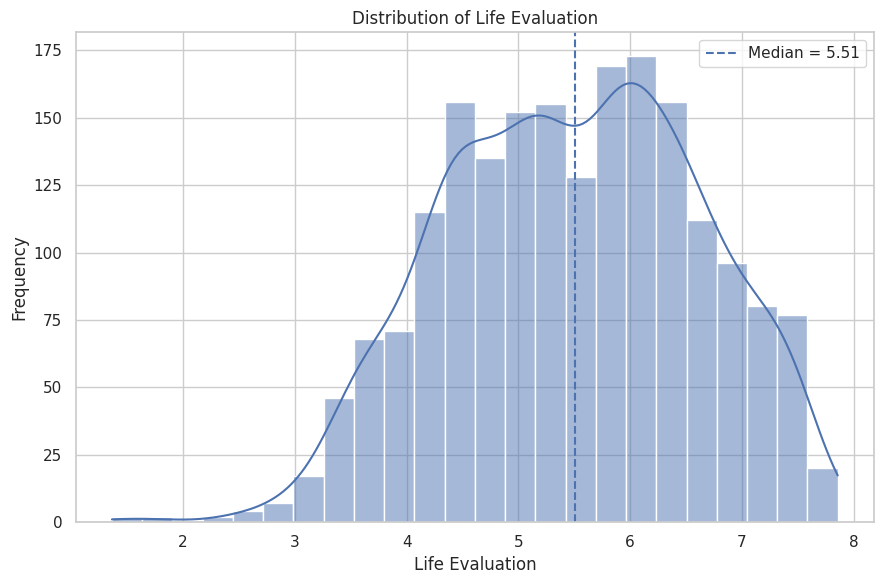

In [17]:
plt.figure(figsize=(9, 6))

sns.histplot(
    analysis["Life_Evaluation"],
    kde=True
)

median_life = analysis["Life_Evaluation"].median()

plt.axvline(
    median_life,
    linestyle="--",
    label=f"Median = {median_life:.2f}"
)

plt.title("Distribution of Life Evaluation")
plt.xlabel("Life Evaluation")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()

plt.savefig(
    "01_happiness_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

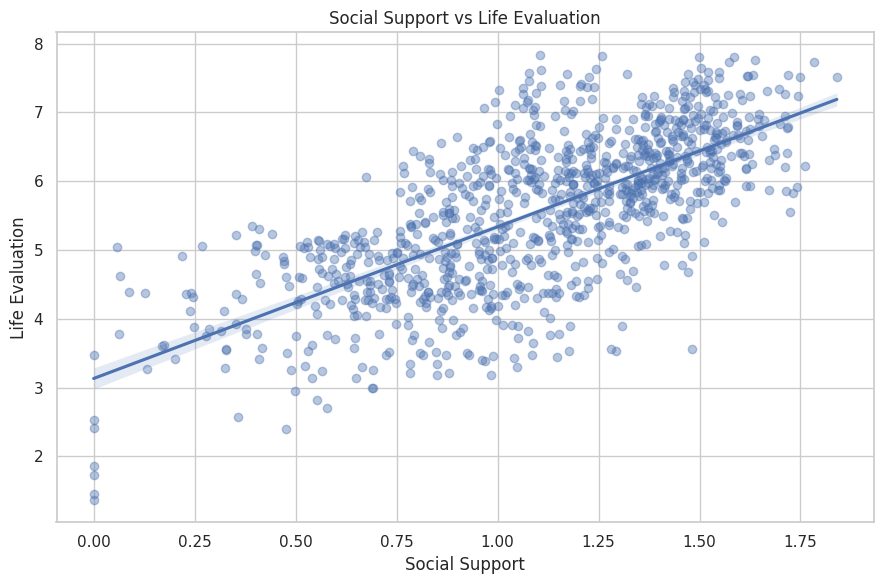

In [19]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=analysis,
    x="Social_Support",
    y="Life_Evaluation",
    scatter_kws={"alpha": 0.4}
)

plt.title(
    "Social Support vs Life Evaluation"
)

plt.xlabel("Social Support")
plt.ylabel("Life Evaluation")

plt.tight_layout()

plt.savefig(
    "02_social_support_vs_happiness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

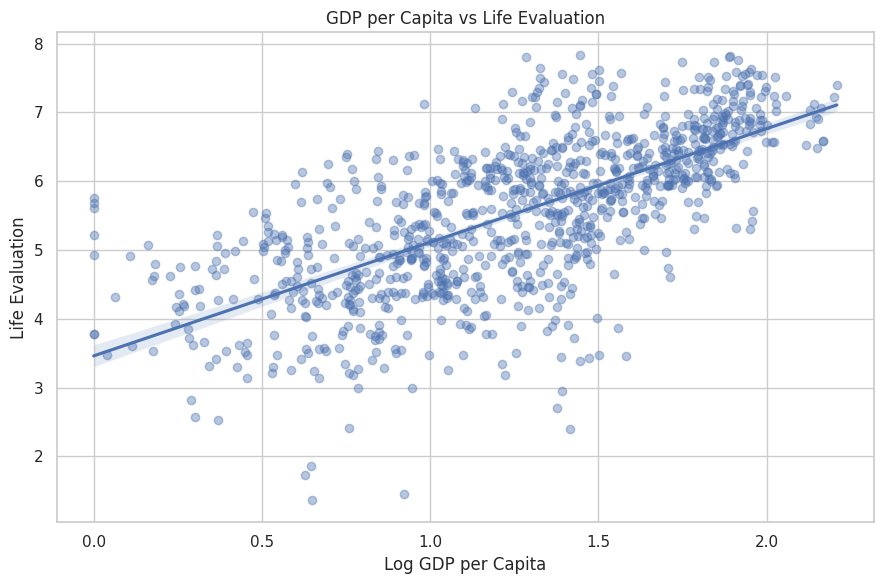

In [20]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=analysis,
    x="GDP_per_Capita",
    y="Life_Evaluation",
    scatter_kws={"alpha": 0.4}
)

plt.title(
    "GDP per Capita vs Life Evaluation"
)

plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Evaluation")

plt.tight_layout()
plt.show()

In [21]:
correlation = analysis[
    ["Life_Evaluation"] + features
].corr()

display(
    correlation["Life_Evaluation"]
    .sort_values(ascending=False)
)

,Life_Evaluation
Life_Evaluation,1.000000
Social_Support,0.701408
GDP_per_Capita,0.681186
Healthy_Life_Expectancy,0.659369
Freedom,0.490965
Corruption,0.426265
Generosity,0.035323


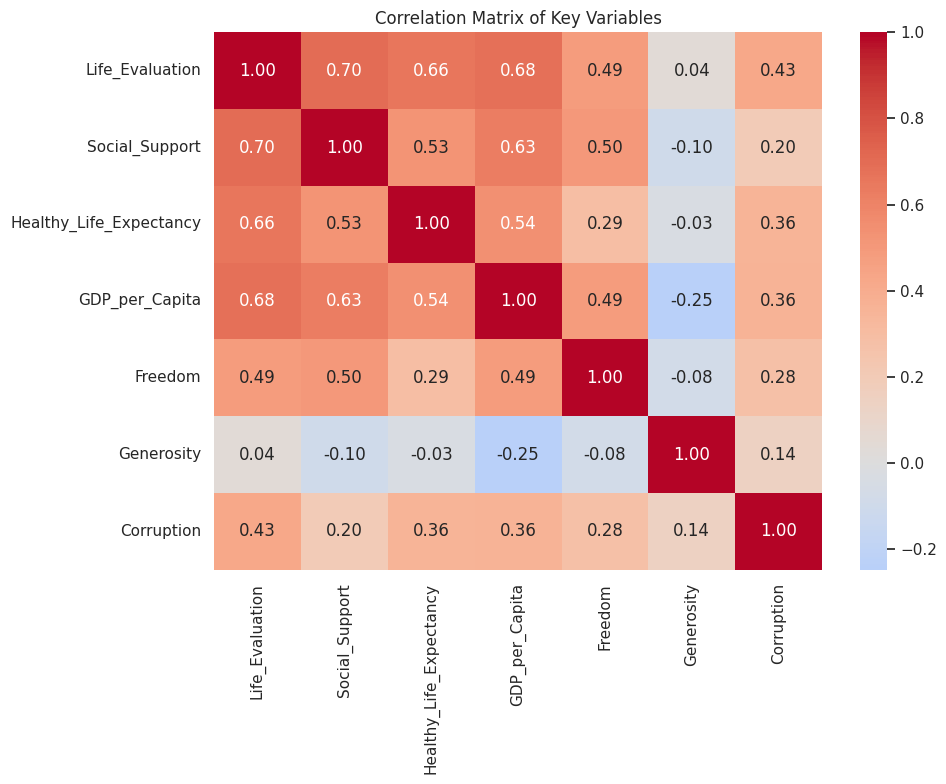

In [22]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of Key Variables"
)

plt.tight_layout()
plt.show()

In [23]:
median_support = analysis[
    "Social_Support"
].median()

print(
    "Median Social Support:",
    median_support
)

Median Social Support: 1.14011859893799


In [24]:
analysis["Support_Group"] = np.where(
    analysis["Social_Support"] >= median_support,
    "High Social Support",
    "Low Social Support"
)

display(
    analysis[
        ["Social_Support", "Support_Group"]
    ].head()
)

,Social_Support,Support_Group
0,1.638,High Social Support
1,1.720,High Social Support
2,1.633,High Social Support
3,1.483,High Social Support
4,1.570,High Social Support


In [25]:
high_support = analysis.loc[
    analysis["Support_Group"] == "High Social Support",
    "Life_Evaluation"
].dropna()

low_support = analysis.loc[
    analysis["Support_Group"] == "Low Social Support",
    "Life_Evaluation"
].dropna()

print(
    "High-support observations:",
    len(high_support)
)

print(
    "Low-support observations:",
    len(low_support)
)

print(
    "\nHigh-support mean:",
    high_support.mean()
)

print(
    "Low-support mean:",
    low_support.mean()
)

High-support observations: 510
Low-support observations: 1433

High-support mean: 6.192130588538973
Low-support mean: 5.221321073872845


In [26]:
t_statistic, p_value = stats.ttest_ind(
    high_support,
    low_support,
    equal_var=False
)

mean_difference = (
    high_support.mean()
    - low_support.mean()
)

print("t-statistic:", t_statistic)
print("p-value:", p_value)
print("Mean difference:", mean_difference)

t-statistic: 21.09544970820199
p-value: 6.830644863979196e-85
Mean difference: 0.9708095146661275


In [28]:
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print(
        "There is statistically significant evidence "
        "that high social support is associated with "
        "higher life evaluation."
    )
else:
    print("Decision: Fail to reject the null hypothesis.")
    print(
        "There is insufficient evidence of a statistically "
        "significant difference."
    )

Decision: Reject the null hypothesis.
There is statistically significant evidence that high social support is associated with higher life evaluation.


In [29]:
n1 = len(high_support)
n2 = len(low_support)

s1 = high_support.std(ddof=1)
s2 = low_support.std(ddof=1)

standard_error = np.sqrt(
    (s1**2 / n1) +
    (s2**2 / n2)
)

welch_df = (
    ((s1**2/n1) + (s2**2/n2))**2
    /
    (
        ((s1**2/n1)**2 / (n1-1))
        +
        ((s2**2/n2)**2 / (n2-1))
    )
)

critical_value = stats.t.ppf(
    0.975,
    welch_df
)

ci_lower = (
    mean_difference
    - critical_value * standard_error
)

ci_upper = (
    mean_difference
    + critical_value * standard_error
)

print(
    f"95% Confidence Interval: "
    f"[{ci_lower:.4f}, {ci_upper:.4f}]"
)

95% Confidence Interval: [0.8805, 1.0611]


In [30]:
pooled_sd = np.sqrt(
    (
        ((n1 - 1) * s1**2)
        +
        ((n2 - 1) * s2**2)
    )
    /
    (n1 + n2 - 2)
)

cohens_d = mean_difference / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: 0.9265432191305546


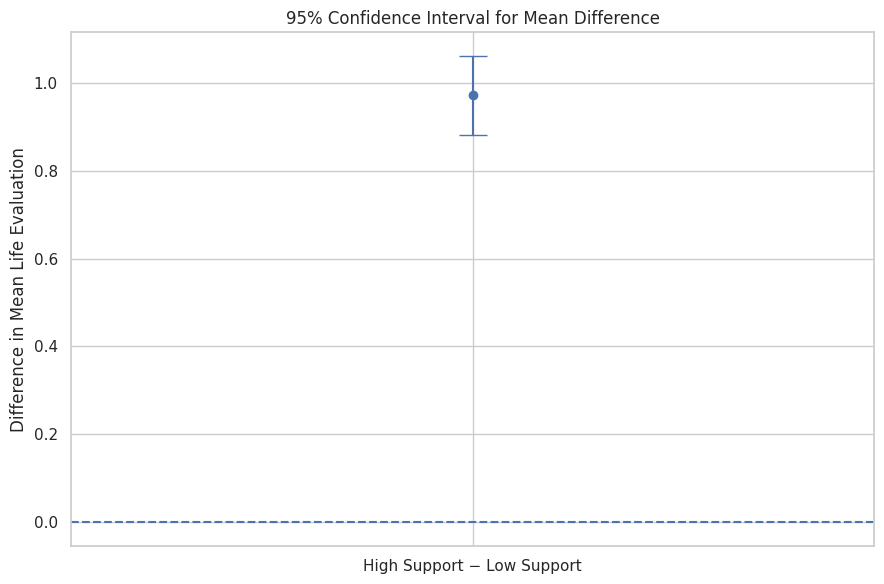

In [31]:
plt.figure(figsize=(9, 6))

plt.errorbar(
    x=[0],
    y=[mean_difference],
    yerr=[
        [mean_difference - ci_lower],
        [ci_upper - mean_difference]
    ],
    fmt="o",
    capsize=10
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xticks(
    [0],
    ["High Support − Low Support"]
)

plt.ylabel(
    "Difference in Mean Life Evaluation"
)

plt.title(
    "95% Confidence Interval for Mean Difference"
)

plt.tight_layout()
plt.show()

In [32]:
correlation_value, correlation_p = stats.pearsonr(
    analysis["Social_Support"],
    analysis["Life_Evaluation"]
)

print(
    "Pearson correlation:",
    correlation_value
)

print(
    "p-value:",
    correlation_p
)

Pearson correlation: nan
p-value: nan


In [33]:
model_df = analysis.dropna(
    subset=features
).copy()

median_life = model_df[
    "Life_Evaluation"
].median()

model_df["Target"] = (
    model_df["Life_Evaluation"]
    >= median_life
).astype(int)

X = model_df[features]
y = model_df["Target"]

print("Median Life Evaluation:", median_life)

print("\nTarget distribution:")
print(y.value_counts())

Median Life Evaluation: 5.714

Target distribution:
Target
1    507
0    506
Name: count, dtype: int64


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 810
Testing observations: 203


In [35]:
model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [36]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [37]:
train_accuracy = model.score(
    X_train,
    y_train
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print(
    f"Training Accuracy: {train_accuracy:.4f}"
)

print(
    f"Testing Accuracy: {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall: {recall:.4f}"
)

print(
    f"F1 Score: {f1:.4f}"
)

print(
    f"ROC-AUC: {roc_auc:.4f}"
)

Training Accuracy: 0.8605
Testing Accuracy: 0.8128
Precision: 0.8137
Recall: 0.8137
F1 Score: 0.8137
ROC-AUC: 0.9241


In [38]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Low Life Evaluation",
            "High Life Evaluation"
        ]
    )
)

                      precision    recall  f1-score   support

 Low Life Evaluation       0.81      0.81      0.81       101
High Life Evaluation       0.81      0.81      0.81       102

            accuracy                           0.81       203
           macro avg       0.81      0.81      0.81       203
        weighted avg       0.81      0.81      0.81       203



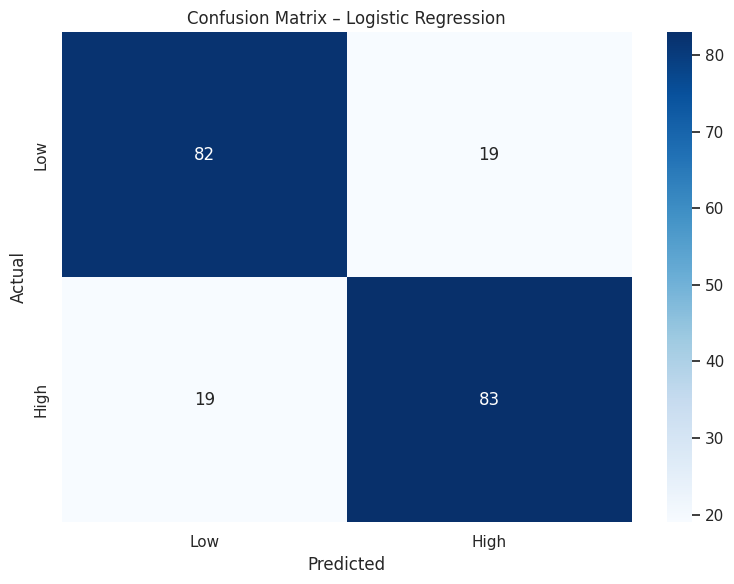

In [39]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low",
        "High"
    ],
    yticklabels=[
        "Low",
        "High"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix – Logistic Regression"
)

plt.tight_layout()
plt.show()

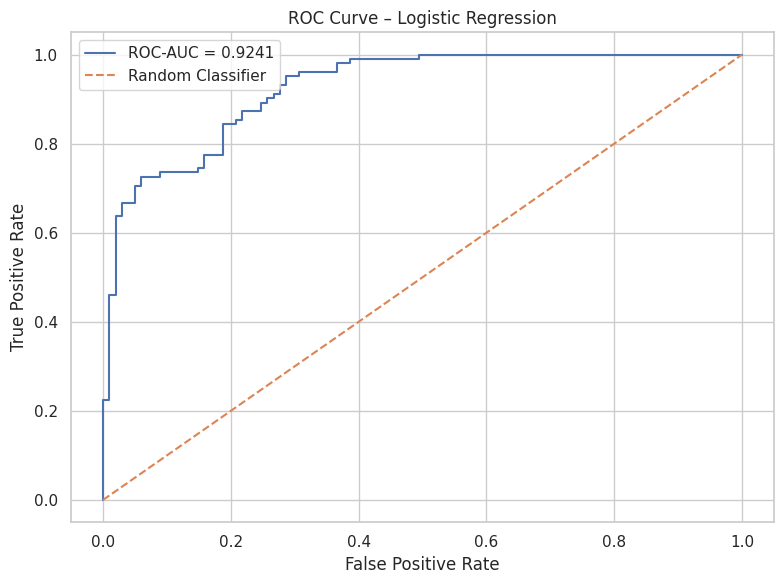

In [40]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve – Logistic Regression"
)

plt.legend()

plt.tight_layout()
plt.show()

In [41]:
classifier = model.named_steps[
    "classifier"
]

coefficients = pd.Series(
    classifier.coef_[0],
    index=features
).sort_values(
    ascending=False
)

display(
    coefficients.to_frame(
        "Logistic Regression Coefficient"
    )
)

,Logistic Regression Coefficient
Social_Support,1.211062
Healthy_Life_Expectancy,1.161062
GDP_per_Capita,1.021024
Freedom,0.656020
Generosity,0.120200
Corruption,0.029399


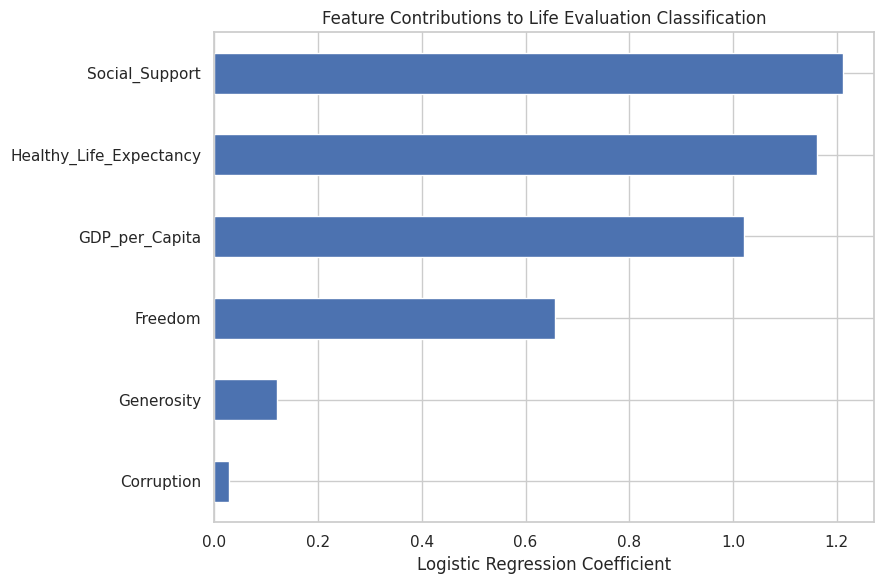

In [42]:
plt.figure(figsize=(9, 6))

coefficients.sort_values().plot(
    kind="barh"
)

plt.xlabel(
    "Logistic Regression Coefficient"
)

plt.title(
    "Feature Contributions to Life Evaluation Classification"
)

plt.tight_layout()
plt.show()

In [43]:
final_results = pd.DataFrame({
    "Measure": [
        "High Social Support Mean",
        "Low Social Support Mean",
        "Mean Difference",
        "t-statistic",
        "t-test p-value",
        "95% CI Lower",
        "95% CI Upper",
        "Cohen's d",
        "Pearson Correlation",
        "Correlation p-value",
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Result": [
        high_support.mean(),
        low_support.mean(),
        mean_difference,
        t_statistic,
        p_value,
        ci_lower,
        ci_upper,
        cohens_d,
        correlation_value,
        correlation_p,
        train_accuracy,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(final_results)

,Measure,Result
0,High Social Support Mean,6.192131e+00
1,Low Social Support Mean,5.221321e+00
2,Mean Difference,9.708095e-01
3,t-statistic,2.109545e+01
4,t-test p-value,6.830645e-85
5,95% CI Lower,8.805259e-01
6,95% CI Upper,1.061093e+00
7,Cohen's d,9.265432e-01
8,Pearson Correlation,NaN
9,Correlation p-value,NaN


In [44]:
print("========== STRATEGIC INSIGHTS ==========\n")

print(
    f"1. Social support correlation with life evaluation: "
    f"{correlation_value:.3f}"
)

print(
    f"2. Difference between high- and low-support groups: "
    f"{mean_difference:.3f}"
)

print(
    f"3. Statistical significance p-value: "
    f"{p_value:.6f}"
)

print(
    f"4. Logistic Regression testing accuracy: "
    f"{accuracy:.2%}"
)

print(
    f"5. Logistic Regression ROC-AUC: "
    f"{roc_auc:.3f}"
)

print("\n========== RECOMMENDATIONS ==========\n")

print(
    "• Strengthen community and social-support systems."
)

print(
    "• Invest in healthcare and healthy-life initiatives."
)

print(
    "• Support economic stability and inclusive opportunities."
)

print(
    "• Encourage individual autonomy and freedom of choice."
)

print(
    "• Use multidimensional well-being indicators for decision-making."
)

========== STRATEGIC INSIGHTS ==========

1. Social support correlation with life evaluation: nan
2. Difference between high- and low-support groups: 0.971
3. Statistical significance p-value: 0.000000
4. Logistic Regression testing accuracy: 81.28%
5. Logistic Regression ROC-AUC: 0.924

========== RECOMMENDATIONS ==========

• Strengthen community and social-support systems.
• Invest in healthcare and healthy-life initiatives.
• Support economic stability and inclusive opportunities.
• Encourage individual autonomy and freedom of choice.
• Use multidimensional well-being indicators for decision-making.


In [45]:
import shutil
import os

os.makedirs("week5_visualizations", exist_ok=True)

visualizations = [
    "01_happiness_distribution.png",
    "02_social_support_vs_happiness.png"
]

for file in visualizations:
    if os.path.exists(file):
        shutil.copy(
            file,
            "week5_visualizations/"
        )

print("Visualization files prepared.")

Visualization files prepared.
